Missing values:
 user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64
--- Head ---
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_

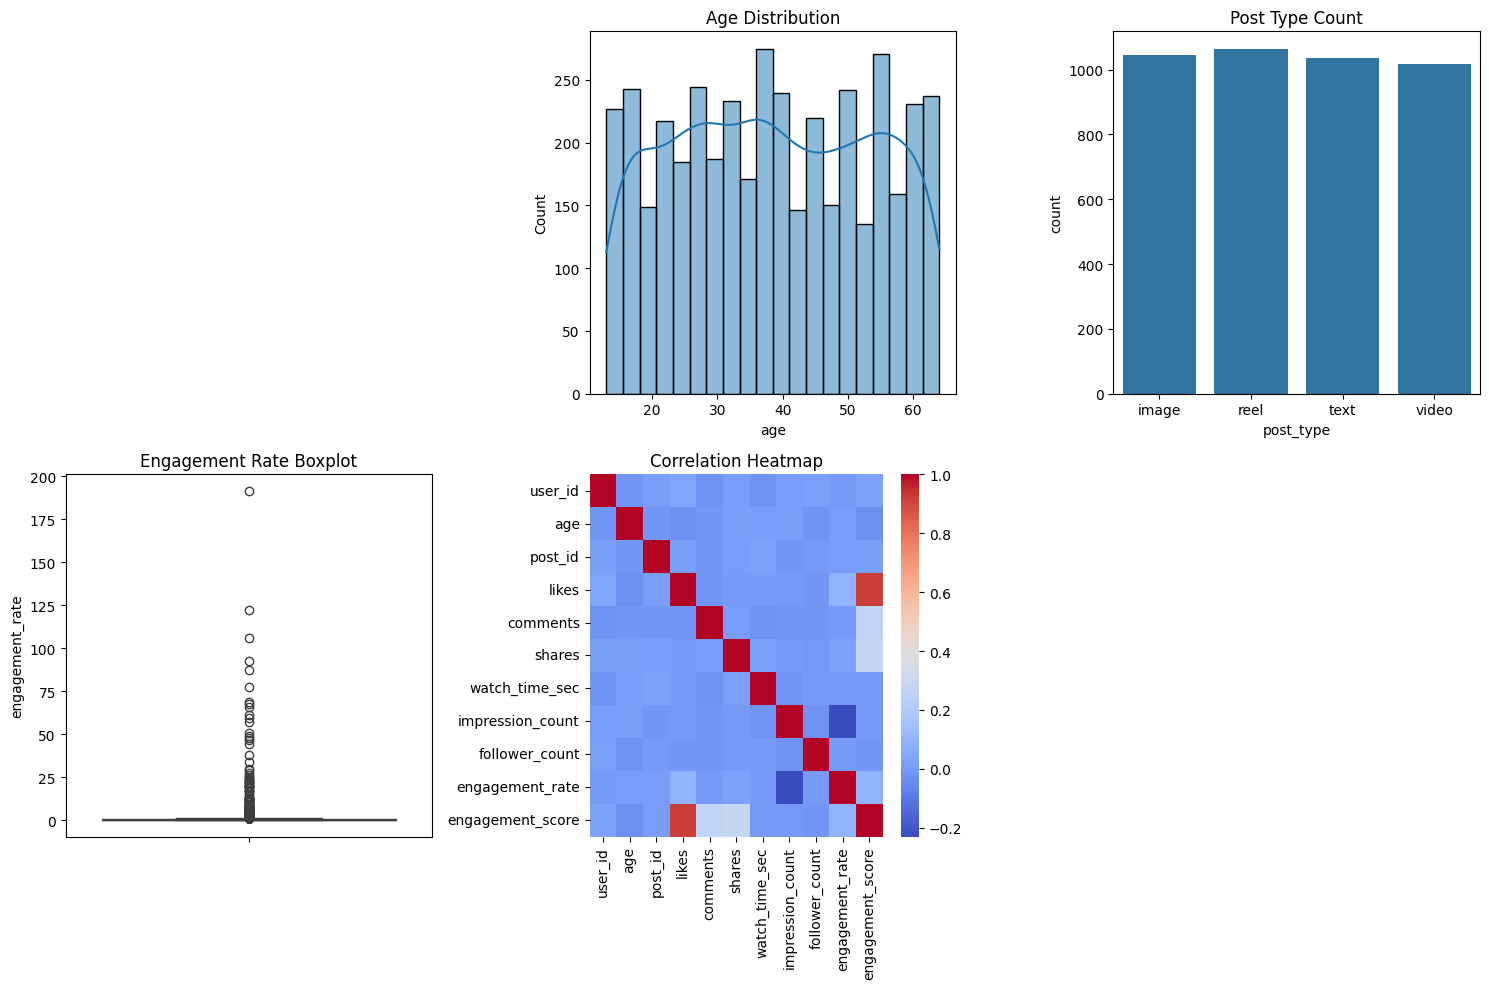

In [9]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# -------------------------------------------------------------
# Task 1: Data Import & Setup
# -------------------------------------------------------------
# Load the dataset
df = pd.read_csv('social media engagement 5000.csv')

# Convert date column to datetime if it exists
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

# -------------------------------------------------------------
# Task 2: Data Cleaning
# -------------------------------------------------------------
# Check and handle missing values
print("Missing values:\n", df.isnull().sum())
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

# -------------------------------------------------------------
# Task 3: Data Exploration using Pandas
# -------------------------------------------------------------
print("--- Head ---")
print(df.head())

print("--- Info ---")
print(df.info())

print("--- Describe ---")
print(df.describe())

# -------------------------------------------------------------
# Task 4: Data Wrangling & Feature Engineering
# -------------------------------------------------------------
# Create new engagement score feature
if 'likes' in df.columns and 'comments' in df.columns and 'shares' in df.columns:
    df['engagement_score'] = df['likes'] + (df['comments'] * 2) + (df['shares'] * 3)

# -------------------------------------------------------------
# Task 5: Statistical Analysis
# -------------------------------------------------------------
metrics = ['likes', 'comments', 'shares', 'watch_time', 'engagement_rate', 'followers']
for col in metrics:
    if col in df.columns:
        print(f"\n--- Statistics for {col} ---")
        print("Mean:", df[col].mean())
        print("Median:", df[col].median())
        print("Standard Deviation:", df[col].std())

# -------------------------------------------------------------
# Task 6: Data Visualization (Min. 8 Plots Required)
# -------------------------------------------------------------
plt.figure(figsize=(15, 10))

# 1. Scatter Plot (Likes vs Impressions)
if 'likes' in df.columns and 'impressions' in df.columns:
    plt.subplot(2, 3, 1)
    sns.scatterplot(data=df, x='impressions', y='likes')
    plt.title('Likes vs Impressions')

# 2. Histogram (Age)
if 'age' in df.columns:
    plt.subplot(2, 3, 2)
    sns.histplot(df['age'], bins=20, kde=True)
    plt.title('Age Distribution')

# 3. Count Plot (Post Type)
if 'post_type' in df.columns:
    plt.subplot(2, 3, 3)
    sns.countplot(data=df, x='post_type')
    plt.title('Post Type Count')

# 4. Box Plot (Engagement Rate)
if 'engagement_rate' in df.columns:
    plt.subplot(2, 3, 4)
    sns.boxplot(y=df['engagement_rate'])
    plt.title('Engagement Rate Boxplot')

# 5. Correlation Heatmap
plt.subplot(2, 3, 5)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()